<a href="https://colab.research.google.com/github/arletedelira-TI/analise-llm-rag-e-agentes-de-ia/blob/main/analise_de_documentos_com_langchain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalando Bibliotecas


In [1]:
%pip install -qU pypdf
%pip install -U langchain
%pip install -U langchain-community
%pip install -U langchain-groq
%pip install langchain-huggingface
%pip install langgraph


# Conectando API KEY


In [2]:
from google.colab import userdata
import os
api_key=userdata.get('GROQ_API_KEY')
os.environ['GROQ_API_KEY'] = api_key

#Importando Chat Groq do LangChain

In [3]:
from langchain_groq import ChatGroq

In [4]:
llm = ChatGroq(model='llama-3.3-70b-versatile')

In [5]:
prompt = '''
	messages: Segundo a NASA quais seriam os benefícios científicos de ir para Marte?
'''

In [6]:
resposta = llm.invoke(prompt)

In [7]:
resposta

AIMessage(content='Os benefícios científicos de ir para Marte incluem a busca por vida no planeta, entendimento da evolução do sistema solar e o estudo da geologia marciana, além de testar tecnologias para futuras missões espaciais tripuladas.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 59, 'total_tokens': 120, 'completion_time': 0.218751911, 'completion_tokens_details': None, 'prompt_time': 0.003188572, 'prompt_tokens_details': None, 'queue_time': 0.176728643, 'total_time': 0.221940483}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4311-3099-7b40-81f6-122b7d751410-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 61, 'total_tokens': 120})

# Adicionando documento pdf para análise

In [8]:
url = 'https://raw.githubusercontent.com/arletedelira-TI/analise-llm-projeto-nasa/main/document-nasa-s-moon-to-mars-strategy-and-objectives-development.pdf'

In [9]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader(url)
pages = []
for page in loader.lazy_load():
	pages.append(page)

/tmp/ipykernel_4394/2066621477.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [10]:
print(f"{pages[0].metadata}\n")

{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.2 (Windows)', 'creationdate': '2023-04-06T17:28:28-04:00', 'moddate': '2023-04-06T17:29:25-04:00', 'trapped': '/False', 'source': 'https://raw.githubusercontent.com/arletedelira-TI/analise-llm-projeto-nasa/main/document-nasa-s-moon-to-mars-strategy-and-objectives-development.pdf', 'total_pages': 78, 'page': 0, 'page_label': '1'}



In [11]:
print(pages[0].page_content)

NASA’S 
MOON TO MARS 
STRATEGY AND 
OBJECTIVES 
DEVELOPMENT
A blueprint for sustained 
human presence and 
exploration throughout 
the Solar System
National Aeronautics and
Space Administration


# Criando uma base de dados vetorial

## Obs: Lembre-se de habilitar a opção GPU no google colab

In [12]:
from langchain_core.vectorstores import InMemoryVectorStore

from langchain_huggingface import HuggingFaceEmbeddings

In [13]:
embed_model = HuggingFaceEmbeddings (model_name="mixedbread-ai/mxbai-embed-large-v1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/114k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [14]:
vector_store = InMemoryVectorStore.from_documents(pages, embed_model)

# Gerando uma resposta com RAG

In [15]:
docs = vector_store.similarity_search("Objective Development Process, k=2")

In [16]:
for doc in docs:
	print(f'Page {doc.metadata["page"]}: {doc.page_content[:300]}\n')

Page 4: Executive Summary
1.0 Introduction
1.1 Scope
2.0 Background and Context
2.1 Why Go?
2.2 Optimal Systems Engineering
2.3 Systems Engineering Risks
2.4 Historical Context and Recent State of Play
3.0 Methodology Principles
4.0 Objectives Development 
5.0 Revised Objectives with Rationale
6.0 What’s Ah

Page 13: objective-baSed approach architect From the riGht / execute From the leFt
Architect from the right 
– work backwards from 
the defined goal and 
establish a complete set 
of elements that will be 
required for success.
NASA’s Moon to Mars strategy is guided by both a robust systems engineering proce

Page 2: Documented here are NASA’s Moon to Mars strategy and top-level goals and objectives, designed to achieve 
the vision to create a blueprint for sustained human presence and exploration throughout the solar system. 
The vision – bold and complex – must be broken down via systems engineering applicatio

Page 42: APPENDIX B: OBJECTIVES DEVELOPMENT PROCESS
In accordance wit

# Pipeline de RAG

In [17]:
retriever = vector_store.as_retriever()

In [18]:
from langchain_core.prompts import ChatPromptTemplate

In [19]:
template = """ You're a helpful assistant that only gives answers bases on the given context. If the answer is not in the context, say "I don't know".

Context: {context}

Question: {question}

Answer:

"""

In [20]:
prompt = ChatPromptTemplate.from_template(template)

In [21]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

In [22]:
chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [23]:
from IPython.display import display, Markdown

In [24]:
response = chain.invoke("What are the Objectives Development Process?")
display(Markdown(response))

The Objectives Development Process, as described in the context, involved the following steps:

1. In November 2021, NASA leadership began to identify top-level goals and objectives related to the blueprint vision and Moon to Mars strategy.
2. The Federated Board facilitated approval of these goals and objectives, which were binned into four distinct tracks: Operations, Infrastructure, Transportation and Habitation, and Science.
3. The original nine goals and 50 draft objectives were released to the public and the NASA workforce in May 2022 with a request for comments by June 2022.
4. NASA received more than 5,000 inputs, which resulted in modification of many objectives and the addition of several new ones.
5. NASA held consultation workshops with both industry and international partners to continue to refine the objectives and identify gaps, welcoming substantive and influential feedback.
6. The resulting revised 10 goals and 63 final objectives reflect a matured strategy for NASA and its partners to develop a blueprint for sustained human presence and exploration throughout the solar system via the Moon to Mars endeavor.

Additionally, the process is also described in Appendix B of the document, but the details of Appendix B are provided in one of the documents, which mentions that:

- The NASA Executive Council tasked the mission directorates to draft a set of top-level goals and objectives necessary to achieve the Moon to Mars endeavor.
- The task would use Federated Board processes to reach consensus.
- The top-level goals and objectives were binned into four distinct tracks: Science, Infrastructure, Transportation and Habitation, and Operations.
- Each of the mission directorate leaders on the Federated Board led the development of corresponding objectives.
- The Federated Board reached consensus on an initial draft set of 45 objectives by March 2022.

# Adicionando mais fontes de informação

In [25]:
from langchain_core.tools import tool

In [26]:
@tool
def pega_contexto(query: str) -> str:
  """Pega o contexto baseado em uma pesquisa."""
  retriever = vector_store.as_retriever()
  resultado = retriever.invoke(query)
  return resultado

In [27]:

def carrega_pdf(url: str):
  loader = PyPDFLoader(url)
  pages = []
  for page in loader.load():
    pages.append(page)

  vectorstore = InMemoryVectorStore.from_documents(pages, embed_model)
  return vectorstore

In [32]:
vector_store_agriculture = carrega_pdf('https://raw.githubusercontent.com/arletedelira-TI/analise-llm-rag-e-agentes-de-ia/main/agriculture.pdf')

In [31]:
vector_store_dengue = carrega_pdf('https://raw.githubusercontent.com/arletedelira-TI/analise-llm-rag-e-agentes-de-ia/main/dengue.pdf')

In [33]:
@tool
def pega_contexto_agriculture(query: str) -> str:
  """Pega o contexto sobre agricultura baseado em uma pesquisa."""
  retriever = vector_store_agriculture.as_retriever()
  resultado = retriever.invoke(query)
  return resultado

In [34]:
@tool
def pega_contexto_dengue(query: str) -> str:
  """Pega o contexto sobre dengue baseado em uma pesquisa."""
  retriever = vector_store_dengue.as_retriever()
  resultado = retriever.invoke(query)
  return resultado

In [35]:
tools = [pega_contexto, pega_contexto_agriculture, pega_contexto_dengue]

In [44]:
pega_contexto_dengue.invoke("Cases of dengue we had since the beginning of 2025?")


[Document(id='f6c215dc-f821-4f5a-9776-1ba399fb36a8', metadata={'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2022-04-05T11:18:49+02:00', 'author': 'ECDC', 'keywords': 'dengue; annual epidemiological report; EU/EEA', 'moddate': '2022-04-05T11:21:18+02:00', 'subject': 'Dengue', 'title': 'Dengue - Annual Epidemiological Report for 2020', 'source': 'https://raw.githubusercontent.com/arletedelira-TI/analise-llm-rag-e-agentes-de-ia/main/dengue.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}, page_content='Suggested citation: European Centre for Disease Prevention and Control. Dengue. In: ECDC. Annual epidemiological report for \n2020. Stockholm: ECDC; 2022. \n \nStockholm, April 2022 \n \n© European Centre for Disease Prevention and Control, 2022. Reproduction is authorised, provided the source is acknowledged. \n \n \n \n \n \n \n \n \n \n \n \n SURVEILLANCE REPORT \nDengue \n \nAnnual Epidemiological Report for 2020 

In [52]:
from langgraph.prebuilt import create_react_agent

In [54]:
system_prompt = """You're a helpful assistant that only gives answer bases on the given context. If the answer is not in the context, say "I don't know"
  - pega_contexto: Tool that returns the context based on the users query if the query is about NASA and space travels.
  - pega_contexto_agriculture: Tool that returns the context based on the users query if the query is about agriculture.
  - pega_contexto_dengue: Tool that returns the context based on the users query if the query is about dengue.
"""

In [55]:
agente_pdf = create_react_agent(model=llm, tools=tools, prompt=system_prompt)

/tmp/ipykernel_4394/840991088.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_pdf = create_react_agent(model=llm, tools=tools, prompt=system_prompt)


In [60]:
agente_pdf.invoke({"messages": [("user", "What are the Objectives Development Process?")]})

{'messages': [HumanMessage(content='What are the Objectives Development Process?', additional_kwargs={}, response_metadata={}, id='a53bb50f-174d-4f49-85b0-fa61bff4081a'),
  AIMessage(content="I don't know", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 5, 'prompt_tokens': 492, 'total_tokens': 497, 'completion_time': 0.017237791, 'completion_tokens_details': None, 'prompt_time': 0.024117187, 'prompt_tokens_details': None, 'queue_time': 0.1727308, 'total_time': 0.041354978}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f432d-68e2-7921-95b3-fd7376f83a13-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 492, 'output_tokens': 5, 'total_tokens': 497})]}

In [62]:
agente_pdf.invoke({"messages": [("user", "What cases dengue?")]})

{'messages': [HumanMessage(content='What cases dengue?', additional_kwargs={}, response_metadata={}, id='50e6bfc2-f8e9-48ae-9454-79b6130bec8e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'gzz9ck2r3', 'function': {'arguments': '{"query":"dengue causes"}', 'name': 'pega_contexto_dengue'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 490, 'total_tokens': 513, 'completion_time': 0.047189283, 'completion_tokens_details': None, 'prompt_time': 0.025135814, 'prompt_tokens_details': None, 'queue_time': 0.177831653, 'total_time': 0.072325097}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f432f-624b-7cc2-b438-1d689e44a9d4-0', tool_calls=[{'name': 'pega_contexto_dengue', 'args': {'query': 'dengue causes'}, 'id': 'gzz9ck2r3', 'type': 'tool_call'}], invalid_tool_calls=[]

# Definindo um grafo com memória

In [63]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import tools_condition

from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage

In [84]:
grafo = StateGraph(MessagesState)

In [85]:
grafo.add_node("assistente", agente_pdf)
grafo.add_node("tools", ToolNode(tools))

In [86]:
grafo.add_edge(START, "assistente")
grafo.add_conditional_edges("assistente",tools_condition)

In [87]:
grafo.add_edge("tools", "assistente")

In [88]:
grafo.add_edge("assistente", END)

In [89]:
memoria = MemorySaver()
app = grafo.compile(checkpointer=memoria)

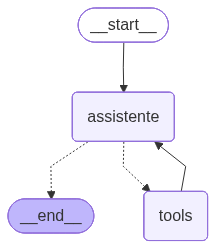

In [90]:
Image(app.get_graph().draw_mermaid_png())

In [114]:
def chat_com_memoria(mensagem_usuario: str, thread_id="1", verbose=False):
  config = {"configurable": {"thread_id": thread_id}}
  messages = app.invoke({"messages": [HumanMessage(content=mensagem_usuario)]}, config)
  if verbose:
      for message in messages['messages']:
        message.pretty_print()
  else:
      messages['messages'][-1].pretty_print()

In [119]:
chat_com_memoria(mensagem_usuario="Why is agriculture crucial for India's economy, and what's its current need?", thread_id="3", verbose = True)

================================ Human Message =================================

Why is agriculture crucial for India's economy, and what's its current need?
================================== Ai Message ==================================
Tool Calls:
  pega_contexto_agriculture (v017a6kqj)
 Call ID: v017a6kqj
  Args:
    query: Importance of agriculture in India's economy and current needs
================================= Tool Message =================================
Name: pega_contexto_agriculture

[Document(id='ce423a7a-fa14-4259-bff3-1e64fdf0890c', metadata={'producer': 'Microsoft® Word 2016', 'creator': 'Microsoft® Word 2016', 'creationdate': '2023-05-18T18:20:05+05:30', 'title': 'Paper Title (use style: paper title)', 'author': 'IEEE', 'moddate': '2023-05-18T18:20:05+05:30', 'source': 'https://raw.githubusercontent.com/arletedelira-TI/analise-llm-rag-e-agentes-de-ia/main/agriculture.pdf', 'total_pages': 4, 'page': 0, 'page_label': '1'}, page_content='International Journal of En

In [121]:
chat_com_memoria(mensagem_usuario="What is the planet NASA is going?", thread_id="3", verbose = False)

================================== Ai Message ==================================

NASA is going to Mars and the Moon as part of its Moon to Mars strategy and objectives development. The agency is planning to send astronauts to Mars in the 2030s and establish a sustainable presence on the lunar surface. The Moon to Mars strategy includes several key objectives, such as sending astronauts to the Moon by 2024, establishing a sustainable presence on the lunar surface, and sending astronauts to Mars in the 2030s. The strategy also includes several key research areas, such as searching for life beyond Earth, characterizing the nature of life elsewhere, and understanding the origin of life in the Solar System.
